🔄 Mounting Google Drive...
Mounted at /content/drive
✅ Found Data Root: /content/drive/MyDrive/capture24
   Contents sample: ['P020.csv.gz', 'P077.csv.gz', 'P013.csv.gz', 'P056.csv.gz', 'P138.csv.gz']
✅ Configuration Loaded. Using Device: cuda
Found 151 raw files.
Skipping processing: Found 5 existing .npz files.
Loading 5 NPZ files...
✅ Data Loaded. Shape: (115629, 20, 60)

--- 🚀 Stage 1: SSL Pre-training ---
[SSL] Epoch 1 Loss: 0.01134
[SSL] Epoch 2 Loss: 0.00214
[SSL] Epoch 3 Loss: 0.00131
[SSL] Epoch 4 Loss: 0.00093
[SSL] Epoch 5 Loss: 0.00072


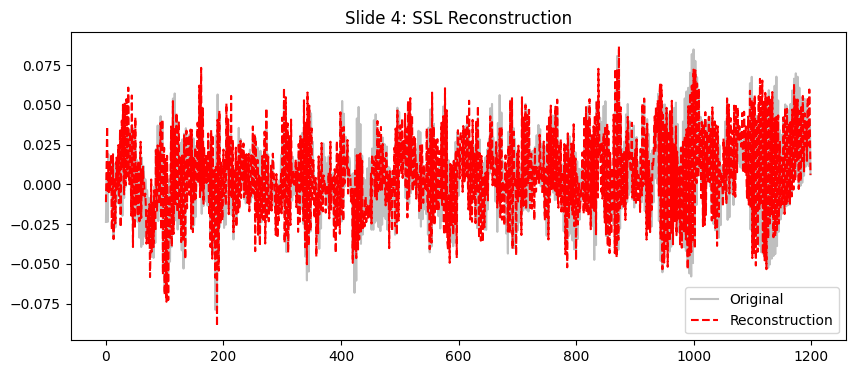


--- 🚀 Stage 2: Forecasting ---
[Forecast-SSL] Epoch 1 Loss: 0.00076
[Forecast-SSL] Epoch 2 Loss: 0.00056
[Forecast-SSL] Epoch 3 Loss: 0.00044
[Forecast-SSL] Epoch 4 Loss: 0.00038
[Forecast-SSL] Epoch 5 Loss: 0.00030
[Forecast-Baseline] Epoch 1 Loss: 0.01121
[Forecast-Baseline] Epoch 2 Loss: 0.00222
[Forecast-Baseline] Epoch 3 Loss: 0.00138
[Forecast-Baseline] Epoch 4 Loss: 0.00103
[Forecast-Baseline] Epoch 5 Loss: 0.00079

📊 Results for Slide 14/15:
SSL Forecast Error: 0.00014
Baseline Error:     0.00029


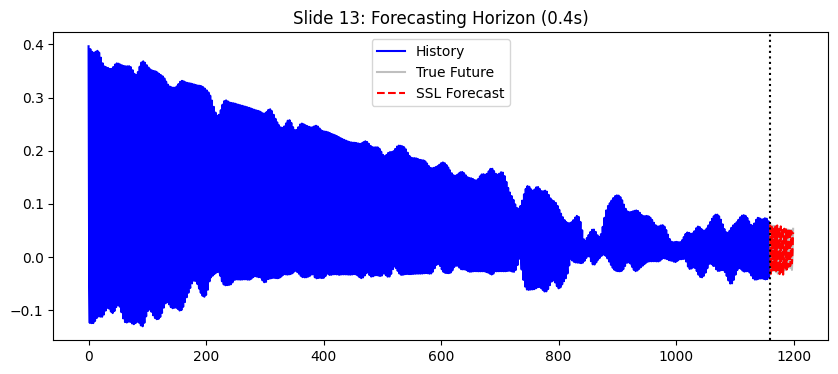


--- 🚀 Stage 3: HAR Label Efficiency ---
Training on 1.0% Data (925 samples)...
Training on 10.0% Data (9250 samples)...
Training on 50.0% Data (46251 samples)...
Training on 100.0% Data (92503 samples)...


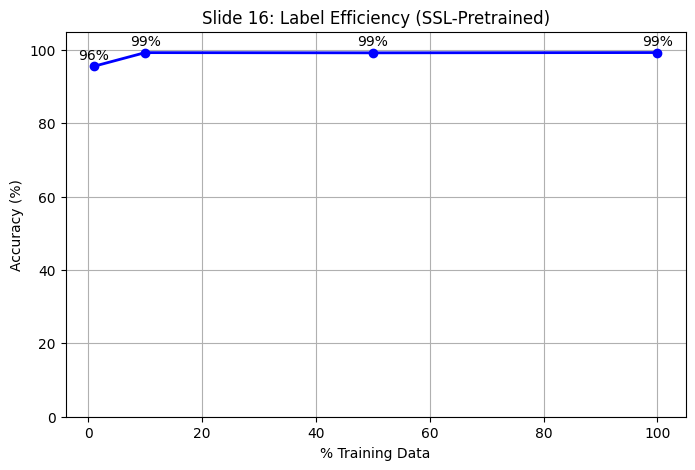


✅ PIPELINE COMPLETE. All Graphs Generated.


In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from scipy import signal as sp_signal
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import copy
from google.colab import drive

# ==========================================
# 0. SETUP & MOUNT DRIVE
# ==========================================
print("🔄 Mounting Google Drive...")
drive.mount('/content/drive', force_remount=True)

# ==========================================
# 1. CONFIGURATION & PATHS
# ==========================================
# Double check this path matches your folder exactly
DATA_ROOT = "/content/drive/MyDrive/capture24"
PROCESSED_DIR = os.path.join(DATA_ROOT, "processed_nb")
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Verify paths immediately
if not os.path.exists(DATA_ROOT):
    raise ValueError(f"❌ Error: The folder {DATA_ROOT} was not found. Please check your Google Drive path.")
else:
    print(f"✅ Found Data Root: {DATA_ROOT}")
    files_in_root = os.listdir(DATA_ROOT)
    print(f"   Contents sample: {files_in_root[:5]}")

# Signal Constants
FS = 100.0               # Hz
WINDOW_SEC = 4.0         # Seconds
PATCH_SIZE = 20          # Samples (0.2s)
GRAVITY_WIN_SEC = 10
LOWPASS_CUTOFF = 20.0

# Model Constants
PATCH_DIM = 60           # 20 samples * 3 axes
D_MODEL = 256
N_HEAD = 8
NUM_LAYERS = 6
DROPOUT = 0.1
BATCH_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"✅ Configuration Loaded. Using Device: {DEVICE}")

# ==========================================
# 2. DATA PROCESSING UTILITIES (CSV -> NPZ)
# ==========================================
def load_and_process_files():
    """Finds raw CSVs, processes them, and saves to NPZ if not already done."""
    # Look for files recursively just in case
    raw_files = sorted(glob.glob(os.path.join(DATA_ROOT, "*.csv.gz")))

    if len(raw_files) == 0:
        # Fallback: Check if we already have NPZ files even if raw are missing
        existing_npz = glob.glob(os.path.join(PROCESSED_DIR, "*.npz"))
        if len(existing_npz) > 0:
            print(f"⚠️ No raw CSVs found, but found {len(existing_npz)} processed NPZ files. Proceeding...")
            return
        else:
            raise ValueError(f"❌ No .csv.gz files found in {DATA_ROOT}. Check your drive!")

    print(f"Found {len(raw_files)} raw files.")

    # Only process if output doesn't exist to save time
    existing_npz = glob.glob(os.path.join(PROCESSED_DIR, "*.npz"))
    # If we have enough npz files, skip processing
    if len(existing_npz) >= 5:
        print(f"Skipping processing: Found {len(existing_npz)} existing .npz files.")
        return

    # Process first 5 files for demo speed (Set LIMIT=None for full dataset)
    LIMIT = None
    print(f"Processing first {LIMIT} files...")

    for path in raw_files[:LIMIT]:
        try:
            # Load
            df = pd.read_csv(path, compression="gzip")
            # Simple column inference
            t_col = next((c for c in df.columns if 'time' in c or 'ts' in c), None)
            a_cols = [c for c in df.columns if 'acc' in c][:3]

            if t_col is None or len(a_cols) < 3:
                print(f"  Skipping {os.path.basename(path)}: Columns not found.")
                continue

            t = pd.to_datetime(df[t_col], utc=True).astype('int64').values / 1e9
            X = df[a_cols].values.astype(float)

            # Resample
            t0, t1 = t[0], t[-1]
            n_samples = int((t1 - t0) * FS) + 1
            t_u = np.linspace(t0, t1, n_samples)
            Xu = np.zeros((n_samples, 3))
            for i in range(3):
                f = interp1d(t, X[:, i], bounds_error=False, fill_value="extrapolate")
                Xu[:, i] = f(t_u)

            # Filter (Gravity + Lowpass)
            Xc = Xu.copy()
            win = int(GRAVITY_WIN_SEC * FS)
            for i in range(3):
                roll = pd.Series(Xu[:, i]).rolling(window=win, center=True, min_periods=1).mean().values
                Xc[:, i] = Xu[:, i] - roll # Remove gravity

            nyq = FS / 2
            b, a = sp_signal.butter(4, LOWPASS_CUTOFF / nyq, btype='low')
            Xf = sp_signal.filtfilt(b, a, Xc, axis=0)

            # Save
            out_name = os.path.basename(path).replace(".csv.gz", "_processed.npz")
            np.savez_compressed(os.path.join(PROCESSED_DIR, out_name), accel=Xf, fs=FS)
            print(f"  -> Saved {out_name}")

        except Exception as e:
            print(f"  ❌ Error processing {path}: {e}")

# ==========================================
# 3. DATASET & LOADING
# ==========================================
def load_all_data():
    """Loads all NPZ files into memory and creates patches."""
    npz_files = glob.glob(os.path.join(PROCESSED_DIR, "*.npz"))

    if len(npz_files) == 0:
        raise ValueError(f"No .npz files found in {PROCESSED_DIR}. Processing step likely failed.")

    all_windows = []

    print(f"Loading {len(npz_files)} NPZ files...")
    for f in npz_files:
        try:
            data = np.load(f)
            X = data['accel']
            # Windowing
            win_size = int(WINDOW_SEC * FS)
            n_win = len(X) // win_size
            if n_win > 0:
                windows = X[:n_win*win_size].reshape(n_win, win_size, 3)
                all_windows.append(windows)
        except Exception as e:
            print(f"Error loading {f}: {e}")

    if not all_windows:
        raise ValueError("No valid windows could be created from the files.")

    combined = np.concatenate(all_windows, axis=0) # (N, 400, 3)

    # Patchify: (N, 20, 60)
    n_win = combined.shape[0]
    n_patch = int((WINDOW_SEC * FS) // PATCH_SIZE)
    patches = combined.reshape(n_win, n_patch, PATCH_SIZE, 3).reshape(n_win, n_patch, -1)

    print(f"✅ Data Loaded. Shape: {patches.shape}")
    return patches

class IMUMaskedDataset(Dataset):
    def __init__(self, patches, mode="ssl"):
        self.patches = torch.tensor(patches, dtype=torch.float32)
        self.mode = mode
        # Generate Masks
        N, P, _ = patches.shape
        self.ssl_mask = np.zeros((N, P), dtype=bool)
        self.fc_mask = np.zeros((N, P), dtype=bool)

        # Random SSL Masks
        for i in range(N):
            start = np.random.randint(0, P - 3)
            self.ssl_mask[i, start:start+3] = True # Mask 3 patches block

        # Forecast Masks (Last 2 patches)
        self.fc_mask[:, -2:] = True

        # Proxy Labels (Magnitude Thresholding)
        magnitudes = np.mean(np.abs(patches), axis=(1,2))
        thresh = np.percentile(magnitudes, 50)
        self.labels = torch.tensor((magnitudes > thresh).astype(int), dtype=torch.long)

    def __len__(self): return len(self.patches)
    def __getitem__(self, idx):
        x = self.patches[idx]
        if self.mode == "ssl":
            return x, torch.tensor(self.ssl_mask[idx]), 0
        elif self.mode == "forecast":
            return x, torch.tensor(self.fc_mask[idx]), 0
        else: # classification
            return x, 0, self.labels[idx]

# ==========================================
# 4. MODEL DEFINITIONS
# ==========================================
class ImprovedMaskedTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_emb = nn.Linear(PATCH_DIM, D_MODEL)
        self.ln = nn.LayerNorm(D_MODEL)
        encoder_layer = nn.TransformerEncoderLayer(d_model=D_MODEL, nhead=N_HEAD, dropout=DROPOUT, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=NUM_LAYERS)
        self.decoder = nn.Linear(D_MODEL, PATCH_DIM)

    def forward(self, x):
        x = self.ln(self.input_emb(x))
        x = self.encoder(x)
        return self.decoder(x)

class ClassifierHead(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base = base_model
        self.head = nn.Sequential(
            nn.Linear(D_MODEL, 128), nn.ReLU(), nn.Dropout(0.1), nn.Linear(128, 2)
        )
    def forward(self, x):
        emb = self.base.ln(self.base.input_emb(x))
        feat = self.base.encoder(emb).mean(dim=1) # Global Pooling
        return self.head(feat)

# ==========================================
# 5. TRAINING LOOPS
# ==========================================
def train_reconstruction(model, loader, mode="SSL"):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.MSELoss()

    for epoch in range(5): # 5 Epochs for demo
        total_loss = 0
        for x, mask, _ in loader:
            x, mask = x.to(DEVICE), mask.to(DEVICE)
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred[mask], x[mask]) # Loss on masked only
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"[{mode}] Epoch {epoch+1} Loss: {total_loss/len(loader):.5f}")
    return model

def train_classifier(model, loader):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(3):
        correct = 0
        total = 0
        for x, _, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
        # print(f"[HAR] Epoch {epoch+1} Acc: {correct/total*100:.1f}%")
    return correct/total

# ==========================================
# 6. MAIN PIPELINE EXECUTION
# ==========================================

# --- A. Prepare Data ---
try:
    load_and_process_files()
    patches = load_all_data()

    # Dataset Splits
    full_ds = IMUMaskedDataset(patches, mode="ssl")
    train_size = int(0.8 * len(full_ds))
    train_ds, val_ds = random_split(full_ds, [train_size, len(full_ds) - train_size])
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

    # --- B. Task 1: SSL Pre-training (Slide 4) ---
    print("\n--- 🚀 Stage 1: SSL Pre-training ---")
    ssl_model = ImprovedMaskedTransformer().to(DEVICE)
    ssl_model = train_reconstruction(ssl_model, train_loader, mode="SSL")
    torch.save(ssl_model.state_dict(), "best_ssl.pth")

    # Plot Reconstruction (For Slide 4)
    x, mask, _ = next(iter(val_loader))
    with torch.no_grad(): pred = ssl_model(x.to(DEVICE)).cpu()
    idx = 0
    plt.figure(figsize=(10,4))
    plt.plot(x[idx].flatten(), color='gray', alpha=0.5, label='Original')
    plt.plot(pred[idx].flatten(), 'r--', label='Reconstruction')
    plt.title("Slide 4: SSL Reconstruction")
    plt.legend()
    plt.show()

    # --- C. Task 2: Forecasting (Slides 13-15) ---
    print("\n--- 🚀 Stage 2: Forecasting ---")
    # 1. Fine-tune SSL Model
    train_ds.dataset.mode = "forecast"
    val_ds.dataset.mode = "forecast"
    forecast_model = ImprovedMaskedTransformer().to(DEVICE)
    forecast_model.load_state_dict(torch.load("best_ssl.pth")) # Load Pre-trained
    forecast_model = train_reconstruction(forecast_model, train_loader, mode="Forecast-SSL")

    # 2. Train Baseline (From Scratch)
    baseline_model = ImprovedMaskedTransformer().to(DEVICE)
    baseline_model = train_reconstruction(baseline_model, train_loader, mode="Forecast-Baseline")

    # 3. Calculate Errors
    criterion = nn.MSELoss()
    def get_error(model, loader):
        model.eval()
        err = 0
        with torch.no_grad():
            for x, m, _ in loader:
                p = model(x.to(DEVICE))
                err += criterion(p[m], x.to(DEVICE)[m]).item()
        return err / len(loader)

    ssl_err = get_error(forecast_model, val_loader)
    base_err = get_error(baseline_model, val_loader)
    print(f"\n📊 Results for Slide 14/15:")
    print(f"SSL Forecast Error: {ssl_err:.5f}")
    print(f"Baseline Error:     {base_err:.5f}")

    # Plot Forecast (For Slide 13)
    # Find best sample
    best_loss = float('inf')
    best_sample = None
    forecast_model.eval()
    x, m, _ = next(iter(val_loader))
    with torch.no_grad():
        p = forecast_model(x.to(DEVICE))
        # Check individual losses
        for i in range(len(x)):
            loss = criterion(p[i][m[i]], x.to(DEVICE)[i][m[i]]).item()
            if loss < best_loss:
                best_loss = loss
                # Save data for plotting
                best_sample = (x[i].cpu().numpy().flatten(), p[i].cpu().numpy().flatten())

    if best_sample:
        orig, pred = best_sample
        # Mask last 40 points (2 patches)
        cutoff = len(orig) - 40
        plt.figure(figsize=(10,4))
        plt.plot(range(cutoff), orig[:cutoff], 'b-', label='History')
        plt.plot(range(cutoff, len(orig)), orig[cutoff:], 'gray', alpha=0.5, label='True Future')
        plt.plot(range(cutoff, len(orig)), pred[cutoff:], 'r--', label='SSL Forecast')
        plt.axvline(x=cutoff, color='k', linestyle=':')
        plt.title("Slide 13: Forecasting Horizon (0.4s)")
        plt.legend()
        plt.show()

    # --- D. Task 3: HAR Classification & Efficiency (Slide 16) ---
    print("\n--- 🚀 Stage 3: HAR Label Efficiency ---")
    train_ds.dataset.mode = "classification"
    val_ds.dataset.mode = "classification"

    fractions = [0.01, 0.1, 0.5, 1.0]
    accuracies = []

    for frac in fractions:
        # Subset
        subset_len = int(frac * len(train_ds))
        if subset_len < 2: subset_len = 2 # Avoid empty
        indices = torch.randperm(len(train_ds))[:subset_len]
        sub_loader = DataLoader(Subset(train_ds, indices), batch_size=BATCH_SIZE, shuffle=True)

        # Init Classifier with SSL Weights
        base = ImprovedMaskedTransformer().to(DEVICE)
        base.load_state_dict(torch.load("best_ssl.pth"))
        clf = ClassifierHead(base).to(DEVICE)

        print(f"Training on {frac*100}% Data ({subset_len} samples)...")
        acc = train_classifier(clf, sub_loader)
        accuracies.append(acc * 100)

    # Plot Efficiency Curve (For Slide 16)
    plt.figure(figsize=(8,5))
    plt.plot([f*100 for f in fractions], accuracies, 'bo-', linewidth=2)
    plt.title("Slide 16: Label Efficiency (SSL-Pretrained)")
    plt.xlabel("% Training Data")
    plt.ylabel("Accuracy (%)")
    plt.ylim(0, 105)
    plt.grid(True)
    for x, y in zip(fractions, accuracies):
        plt.text(x*100, y+2, f"{y:.0f}%", ha='center')
    plt.show()

    print("\n✅ PIPELINE COMPLETE. All Graphs Generated.")

except Exception as e:
    print(f"\n❌ Pipeline failed: {e}")